# Optimizer Ablation Summary

This notebook reads the `evaluation.txt` files in the current optimizer ablation directory and provides:

1. A summary table of `PSNR / MSE / MAE`.
2. Image overviews for `comparison.png`, `loss_curve.png`, `metric_curves.png`, and `final_reconstruction.png`.


In [9]:
from pathlib import Path
import math
import re

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

try:
    import pandas as pd
except ImportError:
    pd = None

BASE_DIR = Path.cwd()
EXPERIMENTS = [
    ('sgd优化器', 'SGD'),
    ('momentum优化器', 'Momentum'),
    ('adam优化器', 'Adam'),
    ('adamw优化器', 'AdamW'),
    ('muon优化器', 'Muon'),
]
IMAGE_NAMES = [
    'comparison.png',
    'loss_curve.png',
    'metric_curves.png',
    'final_reconstruction.png',
]

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.unicode_minus'] = False


In [10]:
def parse_evaluation_txt(path: Path):
    text = path.read_text(encoding='utf-8')

    def extract(metric: str) -> float:
        match = re.search(rf'{metric}:\s*([0-9.]+)', text)
        if match is None:
            raise ValueError(f'Cannot find {metric} in {path}')
        return float(match.group(1))

    return {
        'PSNR': extract('psnr'),
        'MSE': extract('mse'),
        'MAE': extract('mae'),
    }


records = []
for folder_name, display_name in EXPERIMENTS:
    eval_path = BASE_DIR / folder_name / 'evaluation.txt'
    if eval_path.exists():
        metrics = parse_evaluation_txt(eval_path)
        metrics['Optimizer'] = display_name
        records.append(metrics)
    else:
        print(f'Missing evaluation file: {eval_path}')

records


[{'PSNR': 10.5858, 'MSE': 0.08738101, 'MAE': 0.20758496, 'Optimizer': 'SGD'},
 {'PSNR': 10.9435,
  'MSE': 0.08047271,
  'MAE': 0.19918978,
  'Optimizer': 'Momentum'},
 {'PSNR': 30.6168, 'MSE': 0.00086761, 'MAE': 0.01985523, 'Optimizer': 'Adam'},
 {'PSNR': 30.1309, 'MSE': 0.0009703, 'MAE': 0.02077659, 'Optimizer': 'AdamW'},
 {'PSNR': 20.3466, 'MSE': 0.00923287, 'MAE': 0.07410043, 'Optimizer': 'Muon'}]

In [11]:
if pd is not None:
    summary_df = pd.DataFrame(records)[['Optimizer', 'PSNR', 'MSE', 'MAE']]
    display(summary_df.style.format({'PSNR': '{:.4f}', 'MSE': '{:.8f}', 'MAE': '{:.8f}'}))
else:
    print('pandas is not installed. Printing raw records instead:')
    for item in records:
        print(item)


,Optimizer,PSNR,MSE,MAE
0,SGD,10.5858,0.08738101,0.20758496
1,Momentum,10.9435,0.08047271,0.19918978
2,Adam,30.6168,0.00086761,0.01985523
3,AdamW,30.1309,0.00097030,0.02077659
4,Muon,20.3466,0.00923287,0.07410043


In [12]:
def show_image_collection(image_name: str, experiments=EXPERIMENTS, ncols: int = 3):
    total = len(experiments)
    nrows = math.ceil(total / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for ax, (folder_name, display_name) in zip(axes, experiments):
        image_path = BASE_DIR / folder_name / image_name
        if image_path.exists():
            image = mpimg.imread(image_path)
            ax.imshow(image)
            ax.set_title(display_name, fontsize=12)
        else:
            ax.text(0.5, 0.5, f'Missing\n{image_name}', ha='center', va='center', fontsize=12)
            ax.set_title(display_name, fontsize=12)
        ax.axis('off')

    for ax in axes[total:]:
        ax.axis('off')

    fig.suptitle(image_name, fontsize=16)
    plt.tight_layout()
    plt.show()


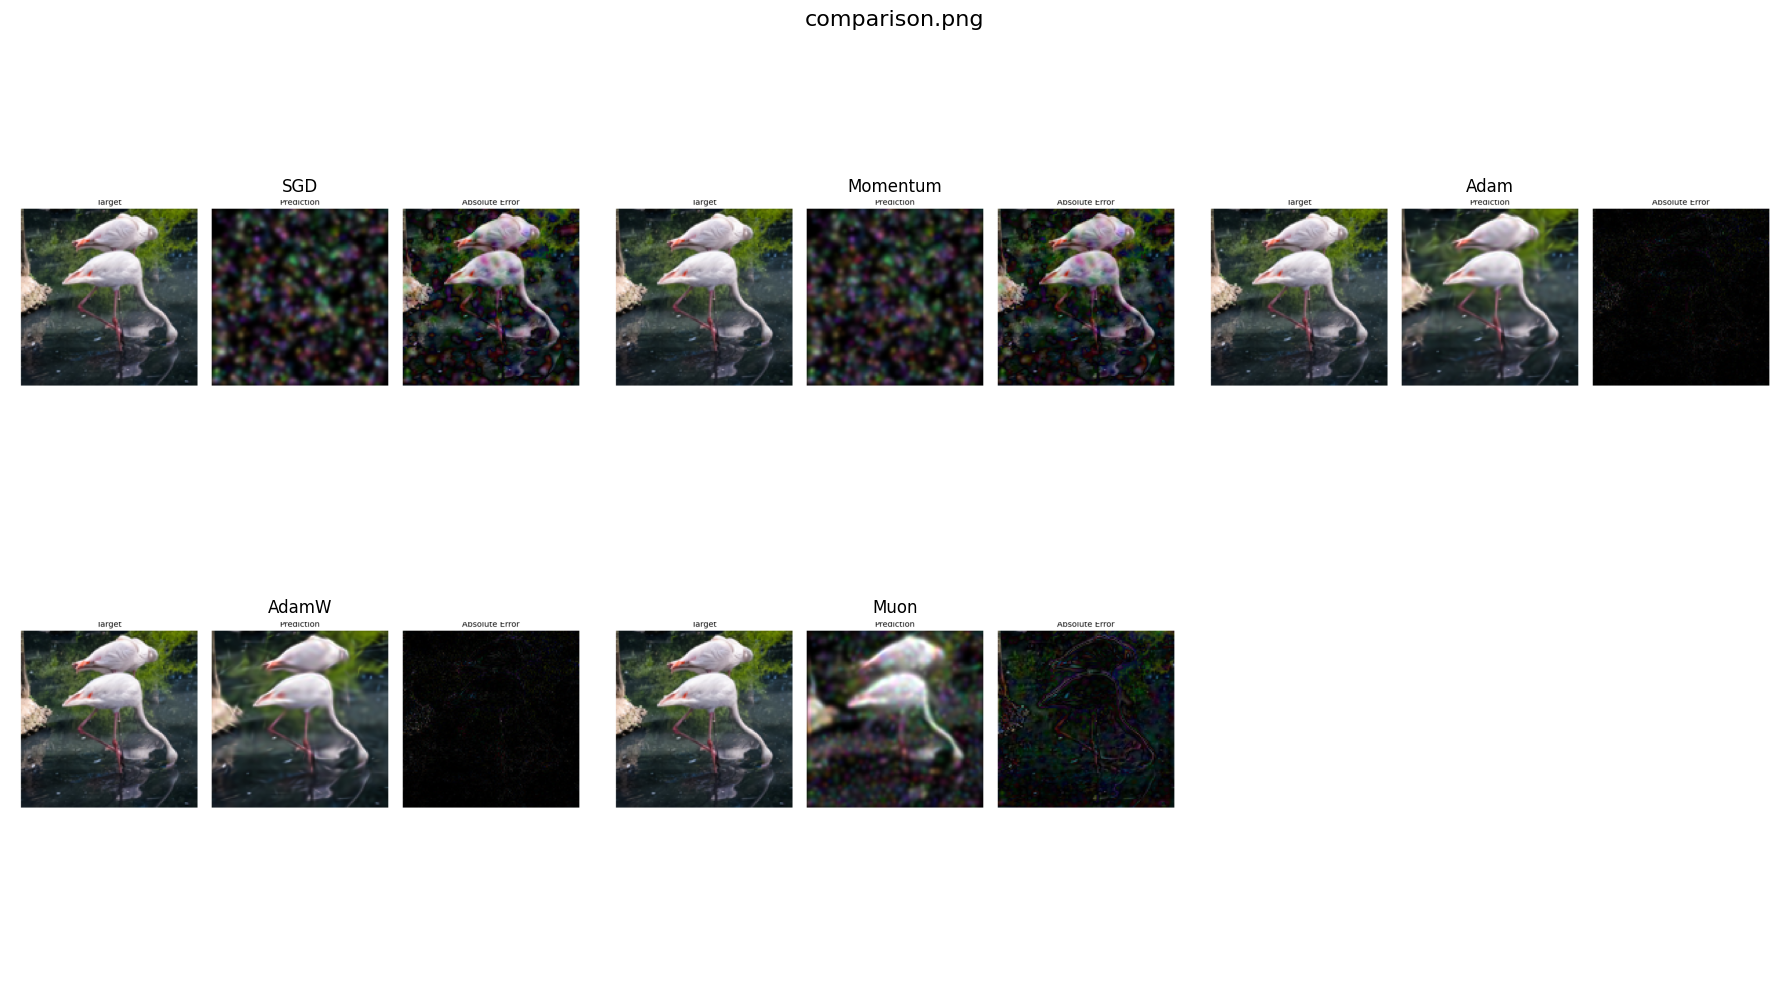

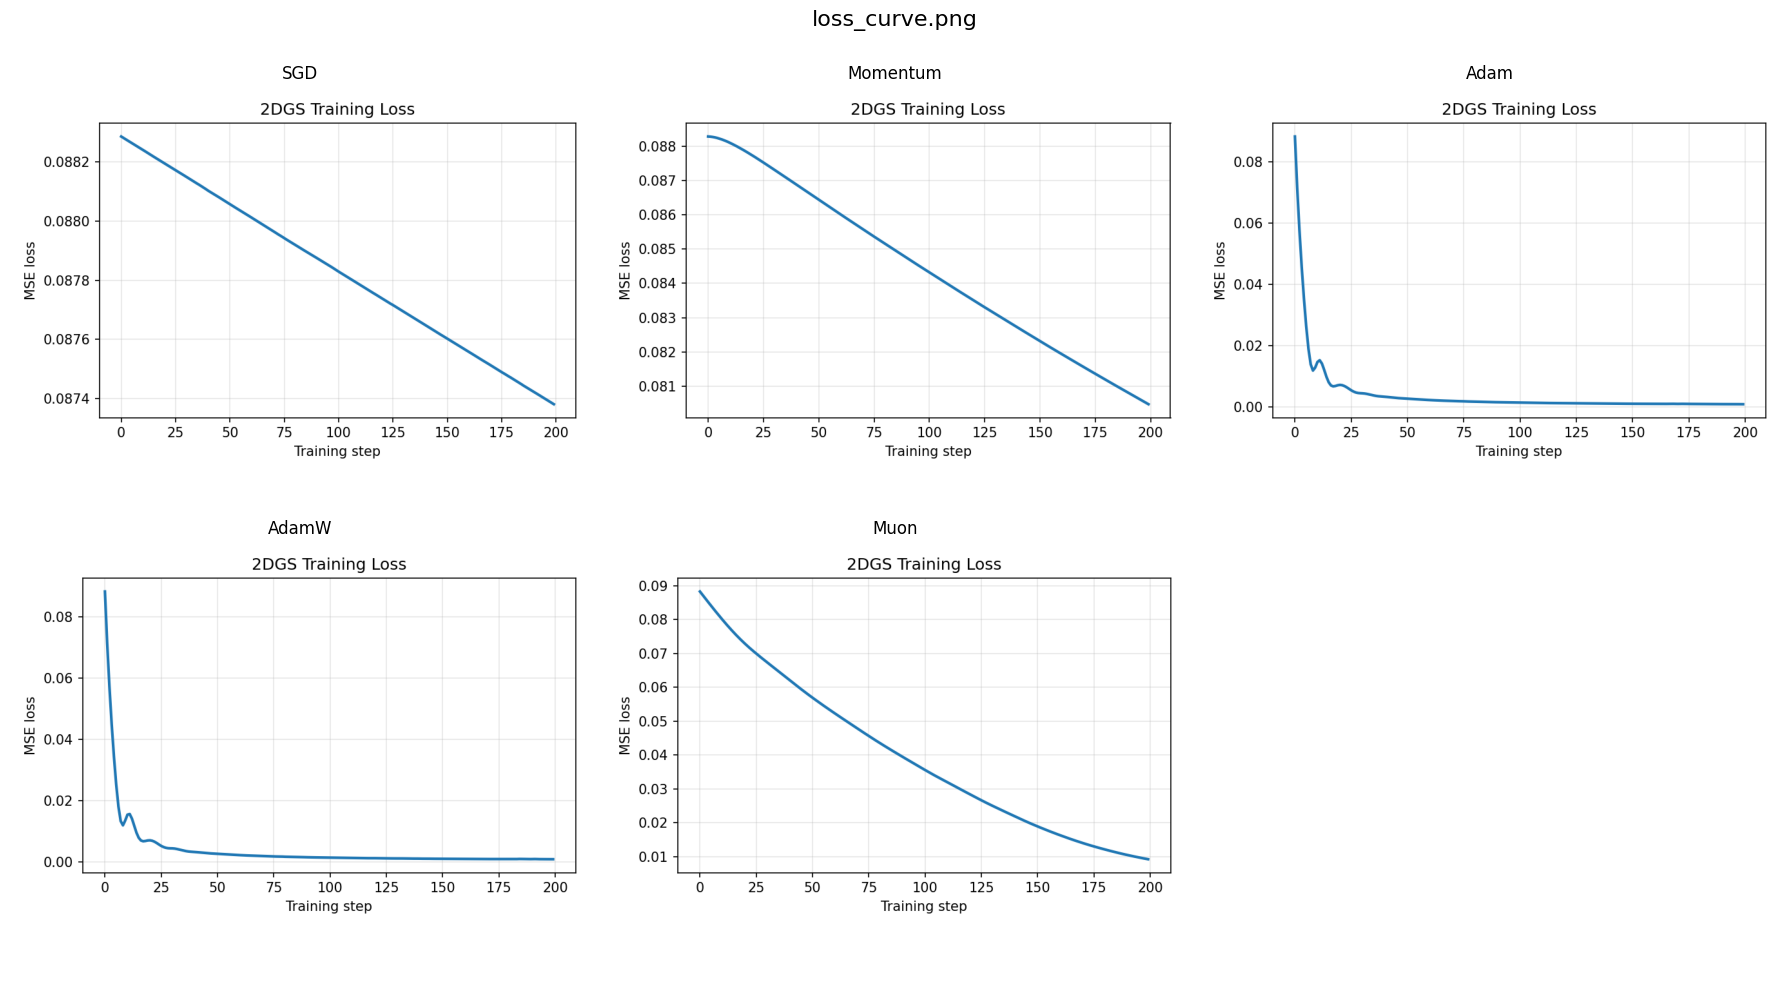

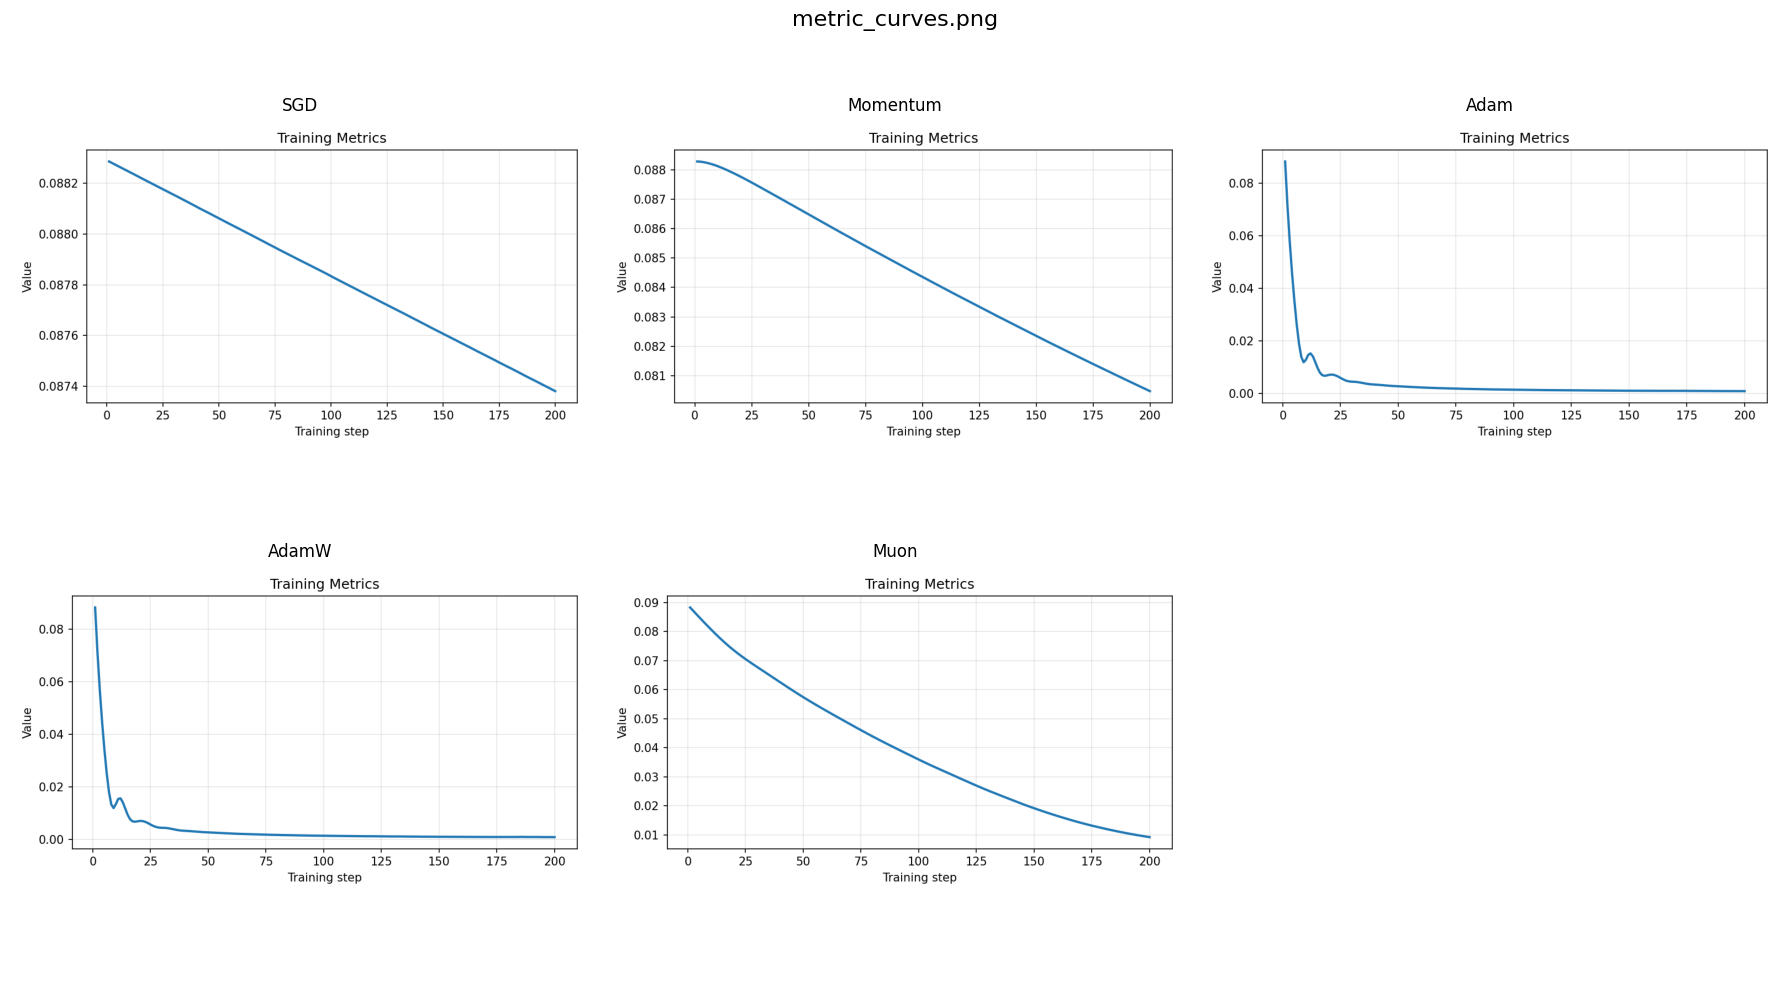

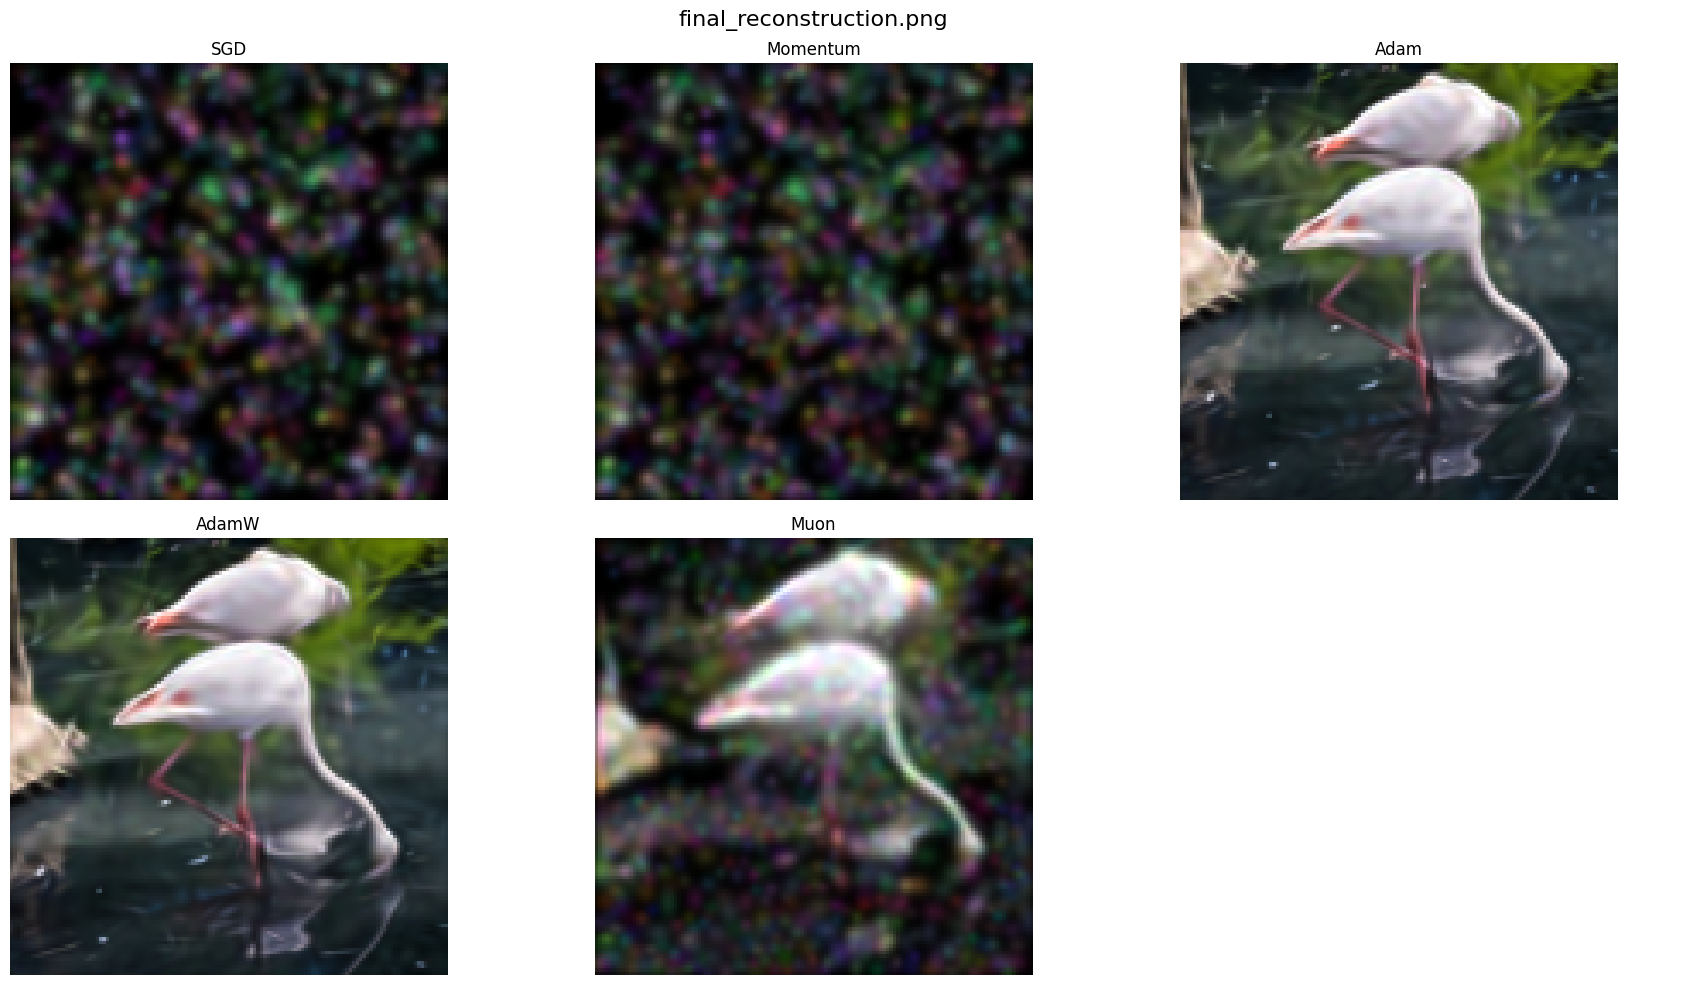

In [13]:
for image_name in IMAGE_NAMES:
    show_image_collection(image_name)
